# 03 — Cohort & Retention Analysis
**Telco Customer Churn Analysis · Future Interns Task 2 · 2026**

---

## Objective
Cohort analysis answers a question that simple averages can't: **how does customer behaviour evolve over time?**

This notebook covers:
- Retention rates by tenure cohort
- Cohort × Contract type heatmap (the showpiece visual)
- Customer Lifetime Value (CLV) by segment
- Month-to-month cohort decay analysis

> **Why cohorts matter:** A 26.5% overall churn rate hides the fact that year-one customers churn at nearly 48% while year-five customers churn at under 7%. Aggregate metrics lie — cohort analysis tells the truth.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df = pd.read_csv('../dataset/cleaned/telco_churn_clean.csv')

# Ensure tenure_group is ordered
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, ordered=True)

print(f"Dataset: {df.shape[0]:,} rows")
print("\nTenure cohort distribution:")
print(df['tenure_group'].value_counts().sort_index())

Dataset: 7,032 rows

Tenure cohort distribution:
tenure_group
0-12m     2175
13-24m    1024
25-36m     832
37-48m     762
49-60m     832
61-72m    1407
Name: count, dtype: int64


## 1. Churn Rate by Tenure Cohort

How does churn risk change as a customer gets older?

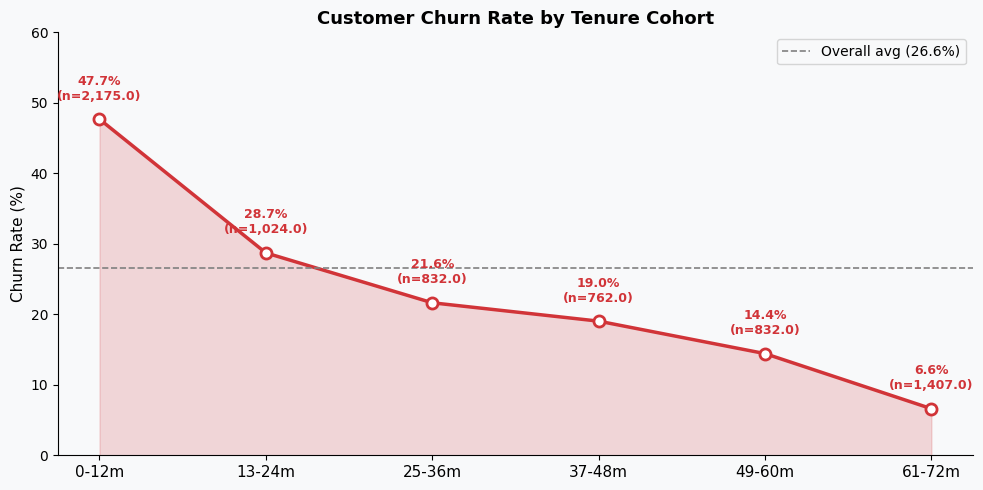

In [10]:
cohort_churn = df.groupby('tenure_group', observed=True)['Churn_bin'].agg(['mean','count'])
cohort_churn['churn_pct'] = cohort_churn['mean'] * 100

fig, ax = plt.subplots(figsize=(10, 5))

# Area chart
ax.fill_between(range(len(cohort_churn)), cohort_churn['churn_pct'],
                alpha=0.18, color='#d13438')
ax.plot(range(len(cohort_churn)), cohort_churn['churn_pct'],
        color='#d13438', linewidth=2.5, marker='o', markersize=8,
        markerfacecolor='white', markeredgecolor='#d13438', markeredgewidth=2)

ax.set_xticks(range(len(cohort_churn)))
ax.set_xticklabels(cohort_churn.index, fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title('Customer Churn Rate by Tenure Cohort', fontweight='bold', fontsize=13)
ax.set_ylim(0, 60)
ax.axhline(df['Churn_bin'].mean()*100, color='grey', linestyle='--',
           linewidth=1.2, label=f"Overall avg ({df['Churn_bin'].mean()*100:.1f}%)")
ax.legend()

# Annotate each point
for i, (idx, row) in enumerate(cohort_churn.iterrows()):
    ax.annotate(f"{row['churn_pct']:.1f}%\n(n={row['count']:,})",
                xy=(i, row['churn_pct']), xytext=(0, 14),
                textcoords='offset points', ha='center', fontsize=9,
                color='#d13438', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/08_cohort_churn_line.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Cohort × Contract Heatmap

This is the **centrepiece visual** of the analysis. It shows where churn concentrates across both tenure and contract dimensions simultaneously.

In [11]:
# Build cohort × contract pivot
heatmap_data = df.groupby(['tenure_group', 'Contract'], observed=True)['Churn_bin'].mean() * 100
heatmap_pivot = heatmap_data.unstack(level='Contract')

# Reorder contract columns
col_order = ['Month-to-month', 'One year', 'Two year']
heatmap_pivot = heatmap_pivot[col_order]

print("Cohort × Contract churn rates (%):")
print(heatmap_pivot.round(1))

Cohort × Contract churn rates (%):
Contract      Month-to-month  One year  Two year
tenure_group                                    
0-12m                   51.4      10.6       0.0
13-24m                  37.7       8.1       0.0
25-36m                  32.5       8.0       2.1
37-48m                  33.5      13.1       2.2
49-60m                  27.8      13.7       4.0
61-72m                  22.2      12.1       3.1


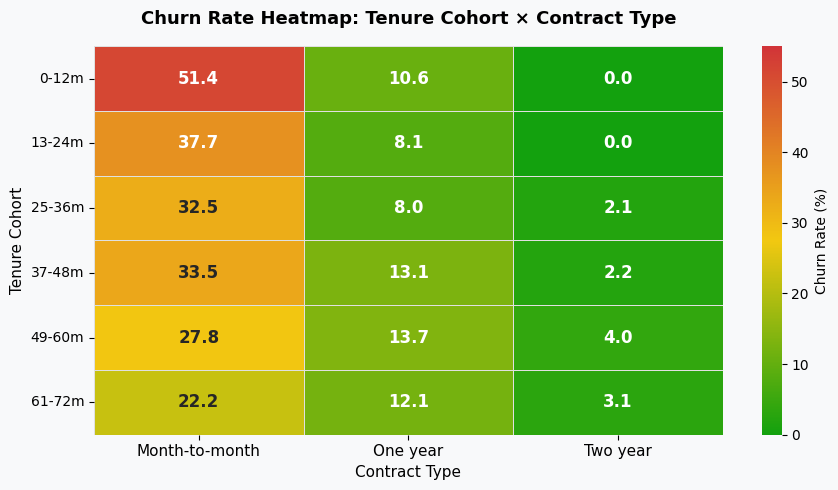


Key reading: The 0-12m × Month-to-month cell is the highest-risk intersection.


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

# Custom red-yellow-green colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    'rg', ['#13a10e', '#f2c811', '#d13438'], N=256
)

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.1f',
    cmap=cmap,
    vmin=0, vmax=55,
    linewidths=0.5,
    linecolor='#e0e0e0',
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax,
    cbar_kws={'label': 'Churn Rate (%)'}
)

ax.set_title('Churn Rate Heatmap: Tenure Cohort × Contract Type',
             fontweight='bold', fontsize=13, pad=16)
ax.set_xlabel('Contract Type', fontsize=11)
ax.set_ylabel('Tenure Cohort', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/09_cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey reading: The 0-12m × Month-to-month cell is the highest-risk intersection.")

## 3. Month-to-Month Cohort Decay

Even within the highest-risk group, does churn improve with tenure?

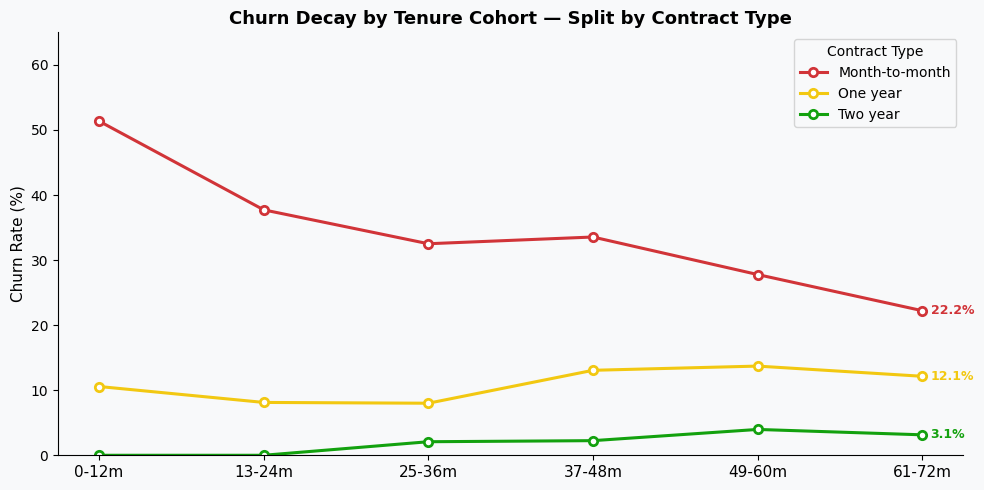

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

contract_colors = {
    'Month-to-month': '#d13438',
    'One year':       '#f2c811',
    'Two year':       '#13a10e'
}

for contract, color in contract_colors.items():
    subset = df[df['Contract'] == contract]
    cohort_rates = subset.groupby('tenure_group', observed=True)['Churn_bin'].mean() * 100
    ax.plot(range(len(cohort_rates)), cohort_rates.values,
            color=color, linewidth=2.2, marker='o', markersize=6,
            markerfacecolor='white', markeredgecolor=color, markeredgewidth=2,
            label=contract)
    # Annotate last point
    ax.annotate(f"{cohort_rates.values[-1]:.1f}%",
                xy=(len(cohort_rates)-1, cohort_rates.values[-1]),
                xytext=(6, 0), textcoords='offset points',
                color=color, fontsize=9, fontweight='bold', va='center')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title('Churn Decay by Tenure Cohort — Split by Contract Type',
             fontweight='bold', fontsize=13)
ax.legend(title='Contract Type', title_fontsize=10)
ax.set_ylim(0, 65)

plt.tight_layout()
plt.savefig('../reports/figures/10_m2m_decay.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Customer Lifetime Value by Segment

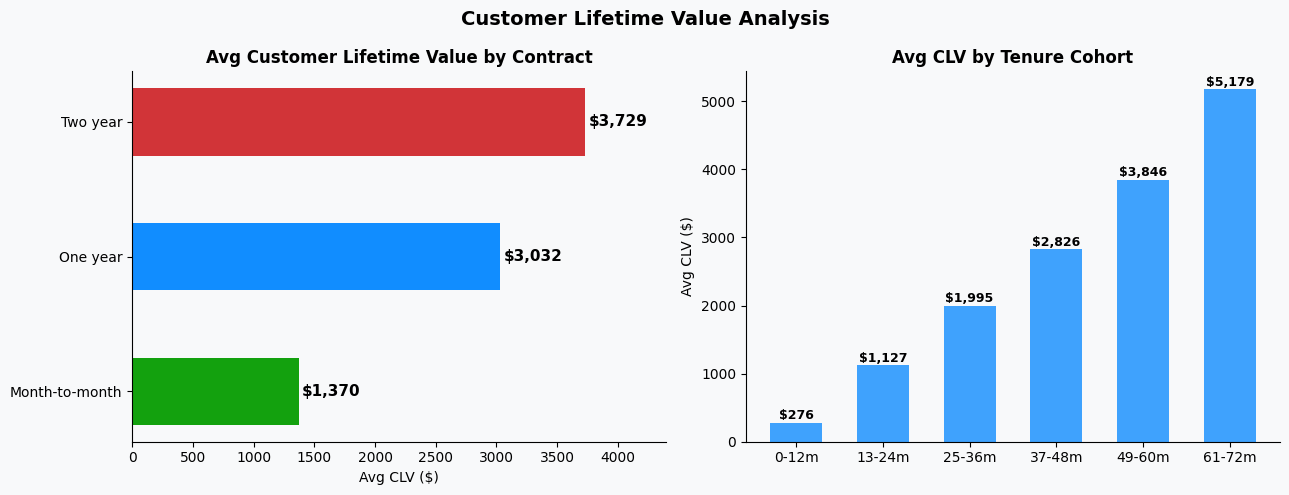

CLV by contract type:
Contract
Month-to-month    1370.0
One year          3032.0
Two year          3729.0
Name: CLV, dtype: float64

CLV uplift (2yr vs M2M): 2.72x


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CLV by contract
clv_contract = df.groupby('Contract')['CLV'].mean().sort_values()
colors_c = ['#13a10e', '#118dff', '#d13438']
bars = axes[0].barh(clv_contract.index, clv_contract.values,
                    color=colors_c, edgecolor='none', height=0.5)
axes[0].set_title('Avg Customer Lifetime Value by Contract', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Avg CLV ($)')
for bar in bars:
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'${bar.get_width():,.0f}', va='center', fontsize=11, fontweight='bold')
axes[0].set_xlim(0, 4400)

# CLV by tenure cohort
clv_cohort = df.groupby('tenure_group', observed=True)['CLV'].mean()
axes[1].bar(range(len(clv_cohort)), clv_cohort.values,
            color='#118dff', alpha=0.8, edgecolor='none', width=0.6)
axes[1].set_xticks(range(len(clv_cohort)))
axes[1].set_xticklabels(clv_cohort.index, fontsize=10)
axes[1].set_title('Avg CLV by Tenure Cohort', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Avg CLV ($)')
for i, val in enumerate(clv_cohort.values):
    axes[1].text(i, val + 50, f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Customer Lifetime Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/11_clv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("CLV by contract type:")
print(df.groupby('Contract')['CLV'].mean().round(0))
print(f"\nCLV uplift (2yr vs M2M): {df[df['Contract']=='Two year']['CLV'].mean() / df[df['Contract']=='Month-to-month']['CLV'].mean():.2f}x")

## 5. Retention Rate by Cohort

Flipping the perspective — instead of churn, what is the *retention* rate?

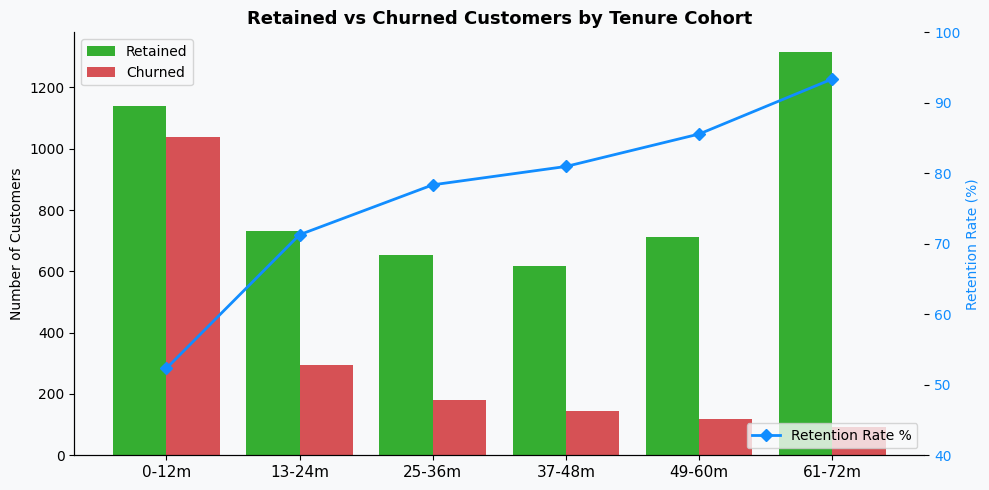

Retention rates by cohort:
              retained  churned  retention_rate
tenure_group                                   
0-12m             1138     1037            52.3
13-24m             730      294            71.3
25-36m             652      180            78.4
37-48m             617      145            81.0
49-60m             713      119            85.6
61-72m            1314       93            93.4


In [15]:
retention = df.groupby('tenure_group', observed=True)['Churn_bin'].agg(
    churn_rate='mean',
    total='count'
)
retention['retention_rate'] = (1 - retention['churn_rate']) * 100
retention['churned'] = (retention['churn_rate'] * retention['total']).astype(int)
retention['retained'] = retention['total'] - retention['churned']

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(retention))
w = 0.4

ax.bar([i - w/2 for i in x], retention['retained'], width=w,
       color='#13a10e', alpha=0.85, label='Retained', edgecolor='none')
ax.bar([i + w/2 for i in x], retention['churned'], width=w,
       color='#d13438', alpha=0.85, label='Churned', edgecolor='none')

ax.set_xticks(list(x))
ax.set_xticklabels(retention.index, fontsize=11)
ax.set_title('Retained vs Churned Customers by Tenure Cohort', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Customers')
ax.legend()

# Retention rate annotation
ax2 = ax.twinx()
ax2.plot(list(x), retention['retention_rate'], color='#118dff', linewidth=2,
         marker='D', markersize=6, label='Retention Rate %', zorder=5)
ax2.set_ylabel('Retention Rate (%)', color='#118dff')
ax2.set_ylim(40, 100)
ax2.tick_params(axis='y', labelcolor='#118dff')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/12_retention_bars.png', dpi=150, bbox_inches='tight')
plt.show()

print("Retention rates by cohort:")
print(retention[['retained','churned','retention_rate']].round(1))

## Summary

| Cohort | Churn Rate | Retention Rate | Key Takeaway |
|---|---|---|---|
| 0–12 months | 47.7% | 52.3% | Highest risk — front-load retention effort |
| 13–24 months | 28.7% | 71.3% | Risk still elevated — engagement critical |
| 25–36 months | 21.6% | 78.4% | Turning point — customer becoming loyal |
| 37–48 months | 19.0% | 81.0% | Past the danger zone |
| 49–60 months | 14.4% | 85.6% | Low risk — focus on upsell |
| 61–72 months | 6.6% | 93.4% | Highly loyal — protect and advocate |

**Next:** `04_churn_insights_report.ipynb` — executive summary and recommendations.